## Pipeline de Modelos de Regressão - Remoção de Features Redundantes

### Neste Notebook analisaremos o treinamento dos modelos de regressão escolhidos com os dados sem as features consideradas redundantes pela análise exploratória anterior. As métricas serão comparadas com os outros treinamentos para a seleção do melhor modelo.

### Importação das bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, 
                             median_absolute_error, mean_squared_log_error, max_error)

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score

### Carregamento e pré-processamento dos dados

In [2]:
raw_data = pd.read_excel('../datasets/ENB2012_data.xlsx')

In [3]:
new_data = raw_data.drop(['X4', 'X5'], axis='columns')

###  Separação de features e target

In [4]:
X = new_data.drop(['Y1', 'Y2'], axis=1)
y = new_data[['Y1', 'Y2']]

### Divisão em treino e teste

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Escalonamento

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Avaliação com métricas

In [7]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Conversão segura para arrays numpy
    y_test = np.asarray(y_test)
    y_pred = np.asarray(y_pred)
    n_outputs = y_test.shape[1]
    
    metrics = {'Modelo': name}
    
    # Função auxiliar para adicionar métricas
    def add_metrics(metric_name, raw_values, avg_value):
        for i in range(n_outputs):
            metrics[f'{metric_name} Y{i+1}'] = raw_values[i]
        metrics[f'{metric_name} Avg'] = avg_value
    
    # R² Score (suporta multioutput nativamente)
    r2_raw = r2_score(y_test, y_pred, multioutput='raw_values')
    r2_avg = r2_score(y_test, y_pred, multioutput='uniform_average')
    add_metrics('R² Score', r2_raw, r2_avg)
    
    # MAE
    mae_raw = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
    mae_avg = mean_absolute_error(y_test, y_pred, multioutput='uniform_average')
    add_metrics('MAE', mae_raw, mae_avg)
    
    # MSE
    mse_raw = mean_squared_error(y_test, y_pred, multioutput='raw_values')
    mse_avg = mean_squared_error(y_test, y_pred, multioutput='uniform_average')
    add_metrics('MSE', mse_raw, mse_avg)
    
    # RMSE (calculado a partir do MSE)
    rmse_raw = np.sqrt(mse_raw)
    rmse_avg = np.sqrt(mse_avg)
    add_metrics('RMSE', rmse_raw, rmse_avg)
    
    # MedAE (calculado individualmente)
    medae_raw = [
        median_absolute_error(y_test[:, i], y_pred[:, i])
        for i in range(n_outputs)
    ]
    medae_avg = np.mean(medae_raw)
    add_metrics('MedAE', medae_raw, medae_avg)
    
    # MSLE (calculado individualmente com verificação)
    msle_raw = []
    for i in range(n_outputs):
        y_true_col = y_test[:, i]
        y_pred_col = y_pred[:, i]
        if np.all(y_true_col >= 0) and np.all(y_pred_col >= 0):
            msle = mean_squared_log_error(y_true_col, y_pred_col)
        else:
            msle = None
        msle_raw.append(msle)
    msle_avg = np.mean(msle_raw) if None not in msle_raw else None
    add_metrics('MSLE', msle_raw, msle_avg)
    
    # Max Error (calculado individualmente)
    maxerror_raw = [
        max_error(y_test[:, i], y_pred[:, i])
        for i in range(n_outputs)
    ]
    maxerror_avg = np.mean(maxerror_raw)
    add_metrics('Max Error', maxerror_raw, maxerror_avg)
    
    return metrics

### Lista de Modelos Escolhidos

In [8]:
base_models = {
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "Ridge": Ridge(),
    "SVR": SVR(),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0)
}

## Predição Múltipla

### Loop de Avaliação

In [9]:
multi_results = []

y_train_multi = new_data[['Y1', 'Y2']].loc[y_train.index]
y_test_multi = new_data[['Y1', 'Y2']].loc[y_test.index]

for name, base_model in base_models.items():
    # Usar MultiOutputRegressor para modelos que não suportam multi-saída nativamente
    multi_model = MultiOutputRegressor(base_model)
    
    metrics = evaluate_model(
        name=f"{name}_multi",
        model=multi_model,
        X_train=X_train_scaled,
        y_train=y_train_multi,  # DataFrame com Y1 e Y2
        X_test=X_test_scaled,
        y_test=y_test_multi     # DataFrame com Y1 e Y2
    )
    multi_results.append(metrics)

df_metrics = pd.DataFrame(multi_results)

### Dataframe de Resultados

In [10]:
df_metrics.T[[4]]

,4
Modelo,XGBoost_multi
R² Score Y1,0.998439
R² Score Y2,0.992929
R² Score Avg,0.995684
MAE Y1,0.263823
MAE Y2,0.439606
MAE Avg,0.351715
MSE Y1,0.162756
MSE Y2,0.65519
MSE Avg,0.408973


### Visualização das Métricas

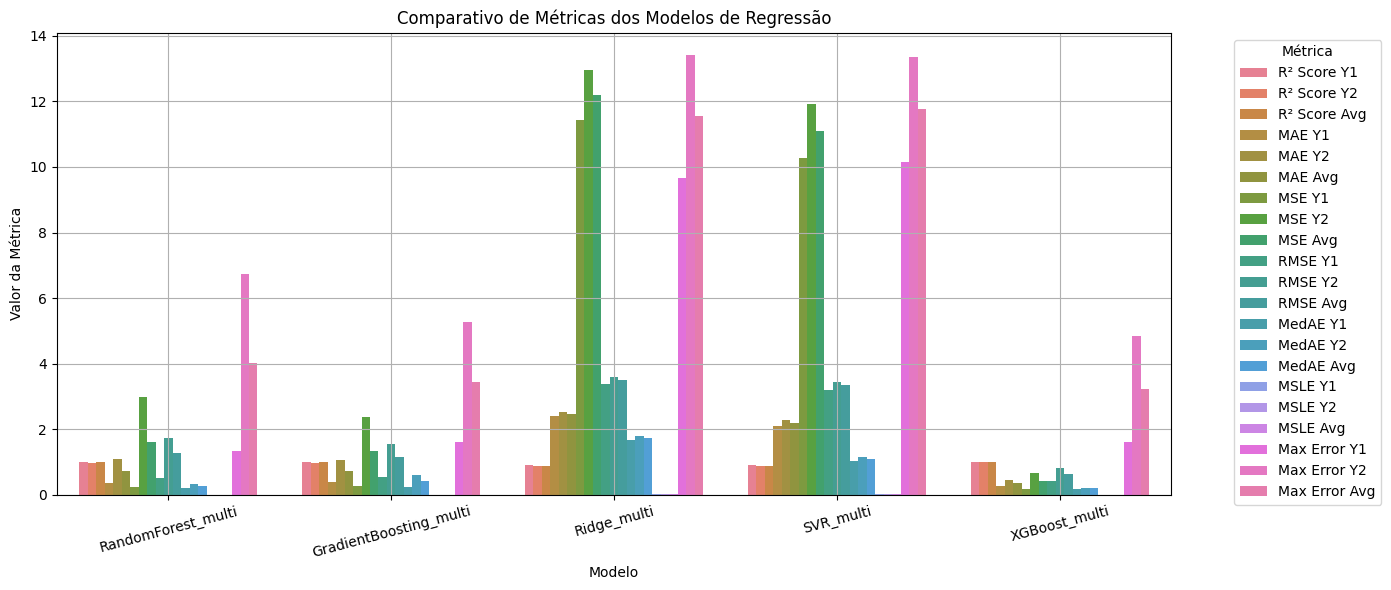

In [11]:
plt.figure(figsize=(14, 6))
sns.barplot(data=df_metrics.melt(id_vars="Modelo"), x="Modelo", y="value", hue="variable")
plt.title("Comparativo de Métricas dos Modelos de Regressão")
plt.ylabel("Valor da Métrica")
plt.xticks(rotation=15)
plt.legend(title="Métrica", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.grid(True)
plt.show()

### Visualização dos resultados

Formato do y_test: (154, 2)
Formato do y_pred: (154, 2)


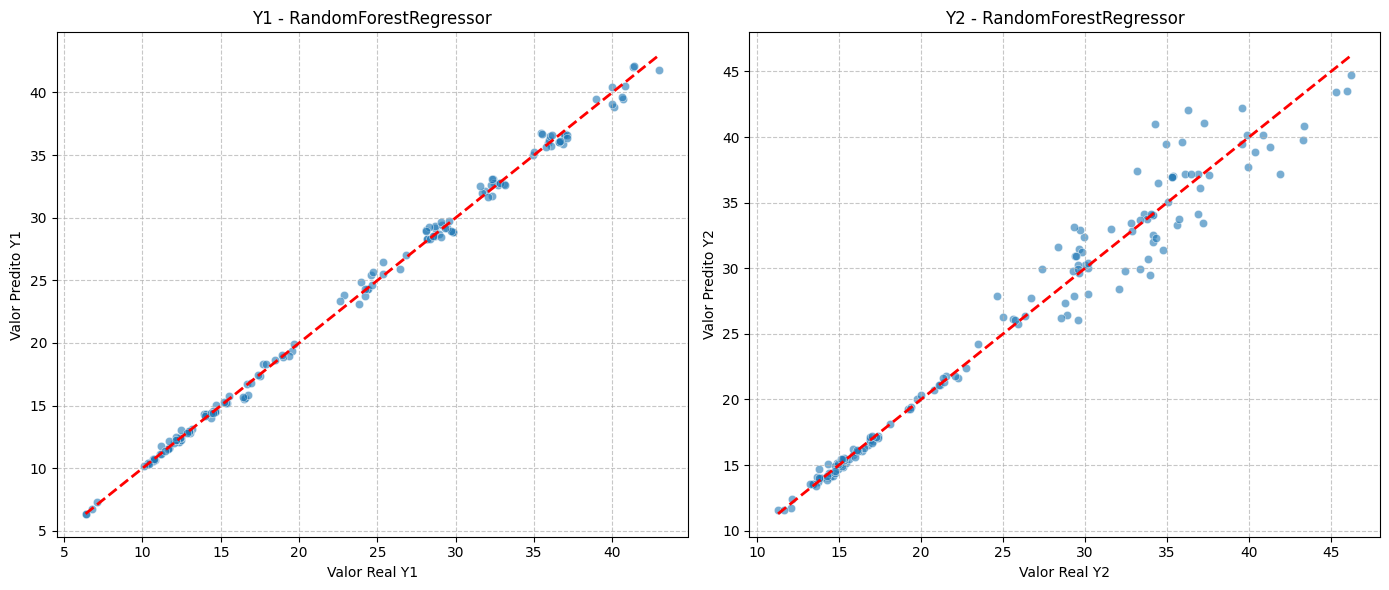

Formato do y_test: (154, 2)
Formato do y_pred: (154, 2)


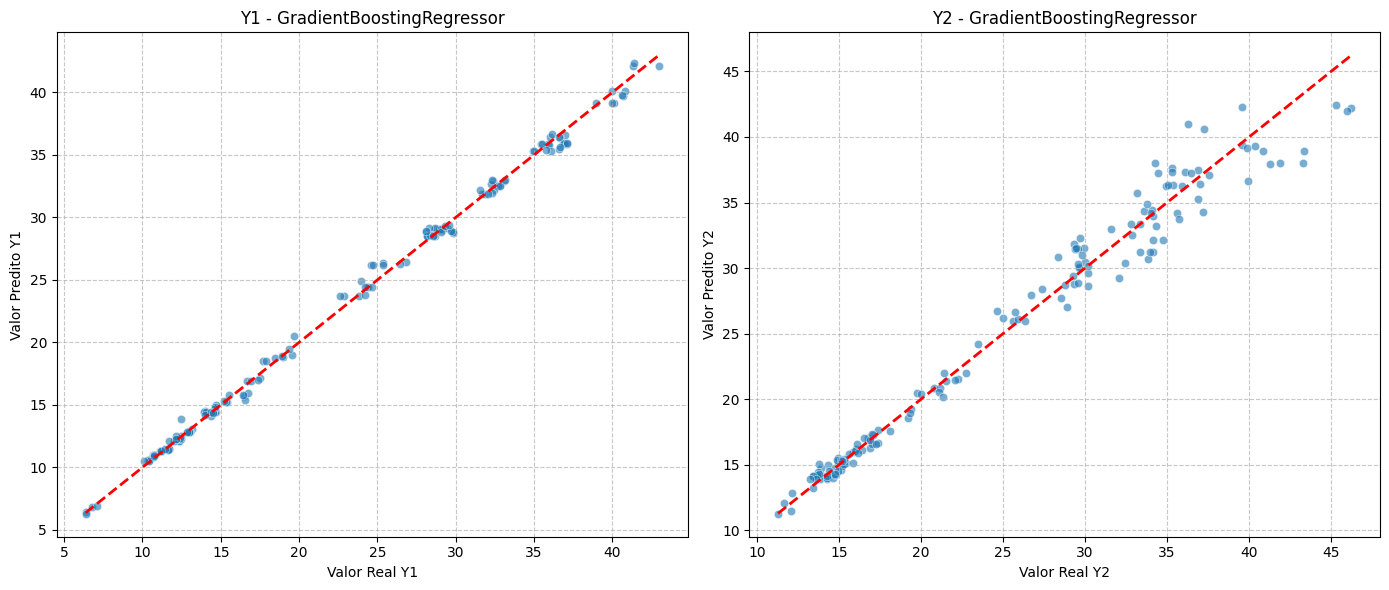

Formato do y_test: (154, 2)
Formato do y_pred: (154, 2)


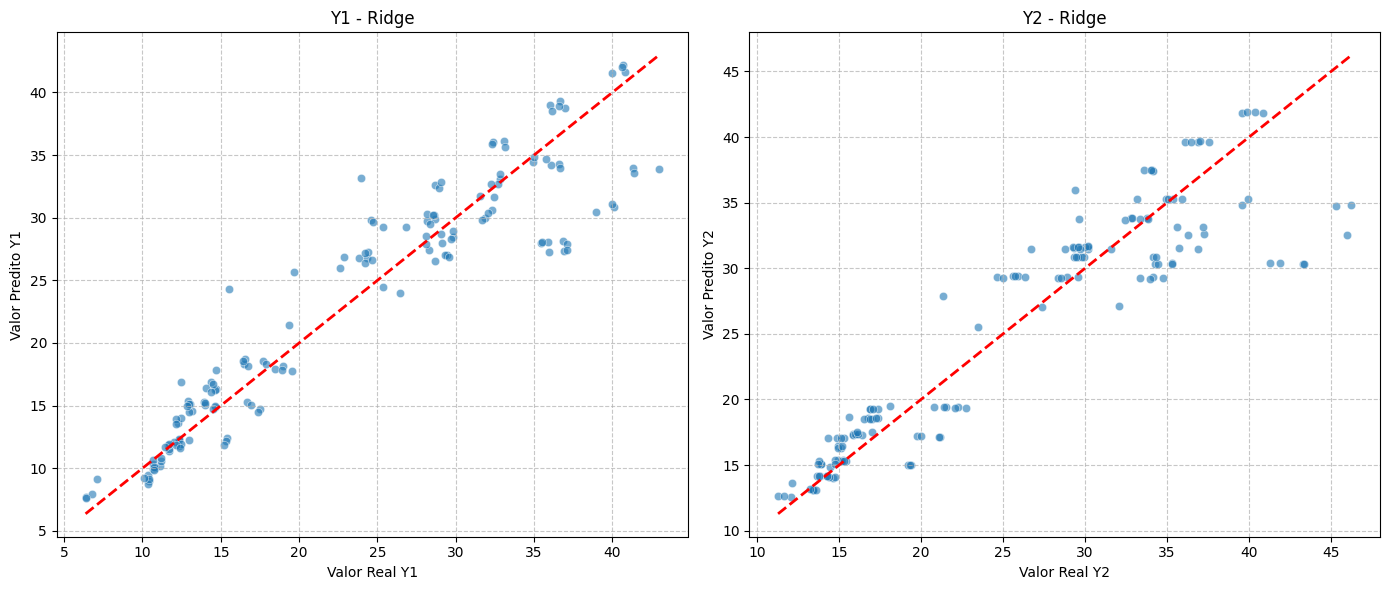

Formato do y_test: (154, 2)
Formato do y_pred: (154, 2)


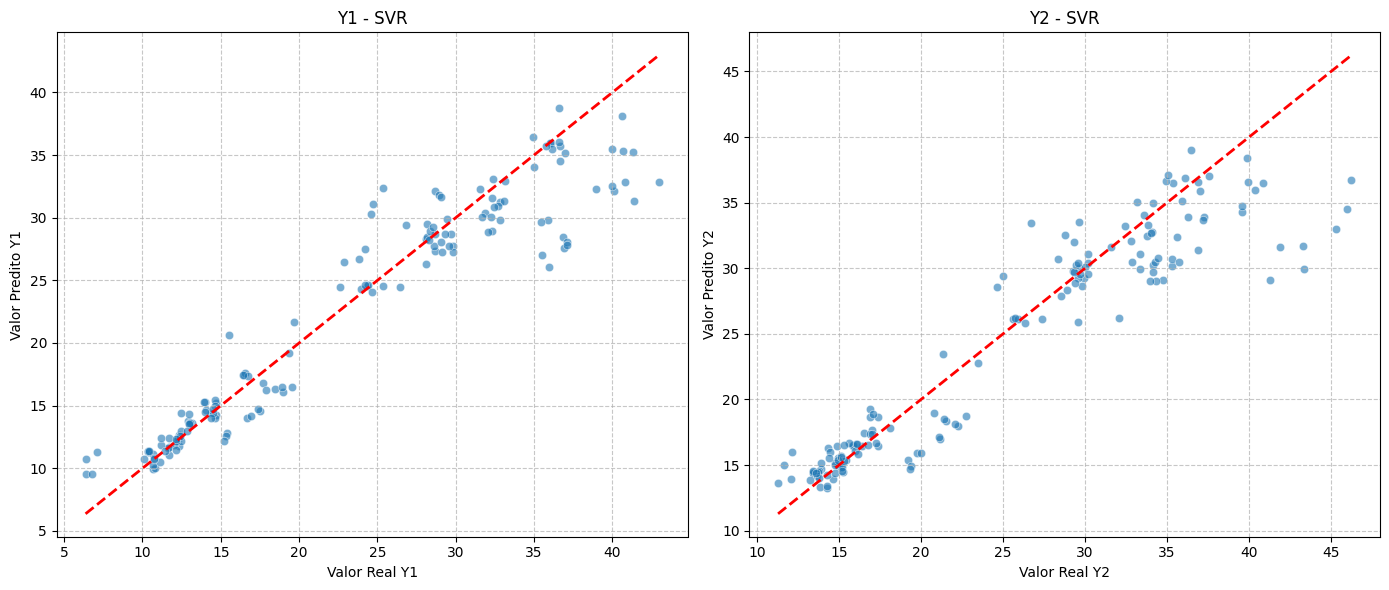

Formato do y_test: (154, 2)
Formato do y_pred: (154, 2)


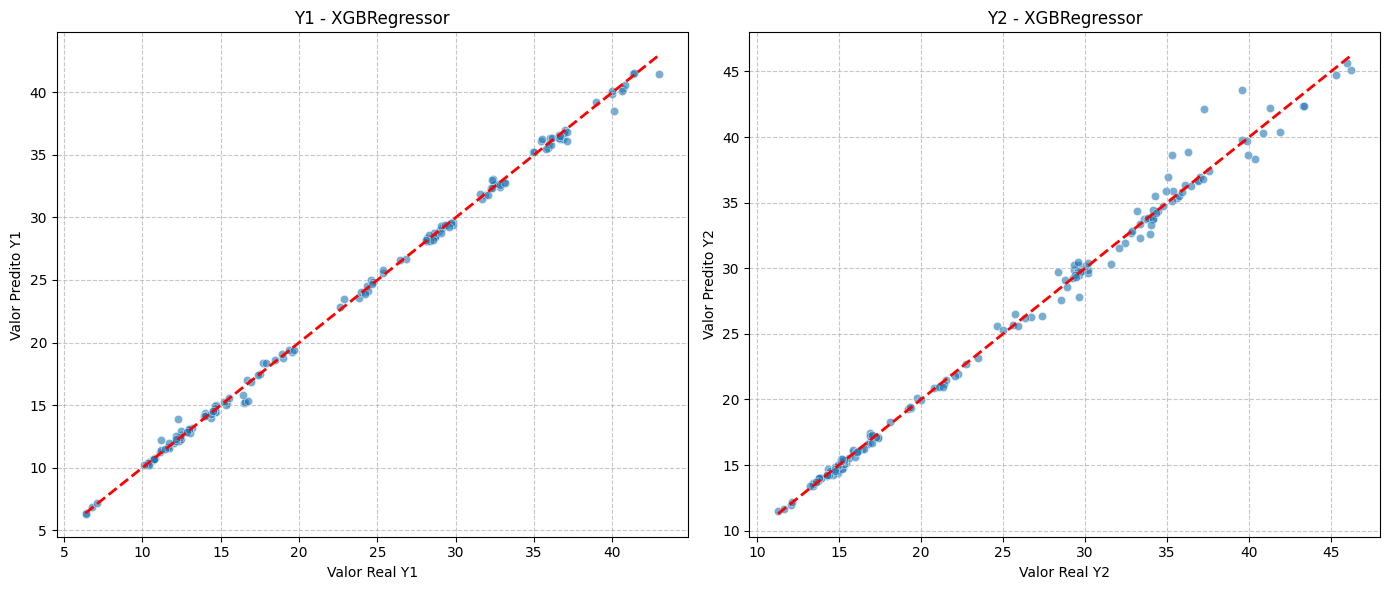

In [12]:
for name, base_model in base_models.items():
    # Criar e treinar o modelo multivariado
    multi_model = MultiOutputRegressor(base_model)
    multi_model.fit(X_train_scaled, y_train_multi)
    
    # Prever e plotar
    y_pred = multi_model.predict(X_test_scaled)
    
    # Converter para arrays
    y_test = np.asarray(y_test_multi)
    y_pred = np.asarray(y_pred)

    # Verificar formato dos dados
    print("Formato do y_test:", y_test.shape)
    print("Formato do y_pred:", y_pred.shape)

    # Plotar os gráficos
    plt.figure(figsize=(14, 6))

    # Gráfico para Y1
    plt.subplot(1, 2, 1)
    sns.scatterplot(x=y_test[:, 0], y=y_pred[:, 0], alpha=0.6, edgecolor='w')
    plt.plot([y_test[:,0].min(), y_test[:,0].max()], 
            [y_test[:,0].min(), y_test[:,0].max()], 'r--', lw=2)
    plt.xlabel("Valor Real Y1")
    plt.ylabel("Valor Predito Y1")
    plt.title(f"Y1 - {type(base_model).__name__}")
    plt.grid(True, linestyle='--', alpha=0.7)

    # Gráfico para Y2
    plt.subplot(1, 2, 2)
    sns.scatterplot(x=y_test[:, 1], y=y_pred[:, 1], alpha=0.6, edgecolor='w')
    plt.plot([y_test[:,1].min(), y_test[:,1].max()], 
            [y_test[:,1].min(), y_test[:,1].max()], 'r--', lw=2)
    plt.xlabel("Valor Real Y2")
    plt.ylabel("Valor Predito Y2")
    plt.title(f"Y2 - {type(base_model).__name__}")
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

### Comparando os resultados obtidos para as métricas com a exclusão das variáveis X4 e X5 com o caso onde foram consideradas todas as variáveis, as métricas sem X4 e X5 também tiveram uma ligeira melhora, como no caso do PCA. Essa melhora é praticamente insignificante considerando os valores das métricas da mesma ordem de grandeza das variáveis target, como o MAE. Mas nesse caso, diferentemente do caso PCA, houve uma melhora nas métricas de Erro Máximo, além disso, uma exclusão de duas variáveis (X4 e X5), sem perda de qualidade do modelo, pode significar um treinamento e predição mais rápido, além de dois campos a menos a serem preenchidos na versão final. Portanto este modelo foi o que melhor se comportou nos testes e será o modelo final escolhido.

| Métrica            | All Vars       | X4X5          | Melhor Coluna |
|---------------------|----------------|---------------|---------------|
| Modelo              | XGBoost_multi | XGBoost_multi | -             |
| R² Score Y1         | 0.998408      | 0.998439      | X4X5          |
| R² Score Y2         | 0.99205       | 0.992929      | X4X5          |
| R² Score Avg        | 0.995229      | 0.995684      | X4X5          |
| MAE Y1              | 0.263596      | 0.263823      | All Vars      |
| MAE Y2              | 0.448628      | 0.439606      | X4X5          |
| MAE Avg             | 0.356112      | 0.351715      | X4X5          |
| MSE Y1              | 0.165944      | 0.162756      | X4X5          |
| MSE Y2              | 0.736659      | 0.65519       | X4X5          |
| MSE Avg             | 0.451301      | 0.408973      | X4X5          |
| RMSE Y1             | 0.407362      | 0.403431      | X4X5          |
| RMSE Y2             | 0.858288      | 0.809438      | X4X5          |
| RMSE Avg            | 0.67179       | 0.63951       | X4X5          |
| MedAE Y1            | 0.164817      | 0.187291      | All Vars      |
| MedAE Y2            | 0.241492      | 0.202349      | X4X5          |
| MedAE Avg           | 0.203154      | 0.19482       | X4X5          |
| MSLE Y1             | 0.000385      | 0.000404      | All Vars      |
| MSLE Y2             | 0.000579      | 0.000533      | X4X5          |
| MSLE Avg            | 0.000482      | 0.000469      | X4X5          |
| Max Error Y1        | 1.666409      | 1.601693      | X4X5          |
| Max Error Y2        | 5.367205      | 4.852225      | X4X5          |
| Max Error Avg       | 3.516807      | 3.226959      | X4X5          |

### Também foram testadas outras combinações de exclusão de variáveis, mas nenhuma delas obteve resultados mais satisfatórios.